# Perturbed TOA OLR expressed as TB change, to test Puojol-Bony interpretations
#### Brian Mapes, March 8 2025 

I want to see how TOA radiation is changed by adiabatic vertical displacements by internal waves. To compute this, the local gradient of vertical profiles of conserved variables $\theta$ and q is multiplied by a finite increment (+1 or +10mb) at each level in the numerical profile, and that increment is added. Note that this reassignment of a value from a higher p is an *upward* motion. Of course $\theta$ must be rescaled to T units for the RT calculation. 

p is the natural coordinate for RT, since it is mass or strictly the number of molecules (times cross-section per molecule) that matters. Gas is sparse so it doesn't matter what spatial layer it is distributed over. However the depth of the layers over which the increments are applied is not uniform, the p array is not evenly spaced. As long as everything is linear, that can be corrected by rescaling the "sensitivity kernels" to adiabatic-q and adiabatic-T changes, normalizing them to a common perturbed-layer depth. A linearity test is the important compuation here, so we tried 1mb and 10mb upward displacements (reasonable amplitudes for ambient internal waves, the latter is used as whiskers in my mseplots-pkg balloon sounding display code for example.  

These plots are TB of irradiance (a hemispheric integral), a little different from radiance (what a satellite sees, which is a bit different at nadir vs. closer to the limb). See my edits to pyarts-lectures notebook (BEM-03-RTcalc) for a radiance computation at nadir. So, slight angle or "limb corrections" could be brought in but that is a very secondary matter.


### Original notebook: 06-olr:
#### arts-lectures Exercise No. 6 -- Outgoing Longwave Radiation (OLR)

Run ARTS on the Jupyter notebook olr.ipynb . This will calculate the spectrum
of outgoing longwave radiation for a midlatitude-summer *BEM-OR TROPICAL* atmosphere.
Our calculation trades accuracy for computational efficiency. For
example, we use only water vapor and carbon dioxide as absorbers.
We use only 300 frequency grid points and approximately 54,000 spectral
lines, whereas for accurate calculations one needs at least 10,000
frequency grid points and 500,000 spectral lines, taking into account
absorbing species like ozone and methane. The script plots the spectral
irradiance, in SI units, as a function of wavenumber. Planck curves
for different temperatures are shown for comparison. We integrate
the whole spectrum to quantify the power per square that is emitted
by the atmosphere (value in title).

In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
from pyarts import xml
from pyarts.arts import convert
from olr_module import calc_olr_from_atmfield, Change_T_with_RH_const, cmap2rgba, planck

os.makedirs("plots", exist_ok=True)

In [3]:
# Read input atmosphere
# atmfield = xml.load("input/midlatitude-summer.xml")
atmfield = xml.load("input/tropical.xml")

# Scale the CO2 concentration
atmfield.scale("abs_species-CO2", 1)

# Add a constant value to the temperature
atmfield.set("T", atmfield.get("T") + 0)

# Add a constant value to the temperature but 
# without changing relative humidity 
atmfield = Change_T_with_RH_const(atmfield,DeltaT=0)

# Calculate the outgoing-longwave radiation
f, olr = calc_olr_from_atmfield(atmfield, verbosity=0)
fall = f 

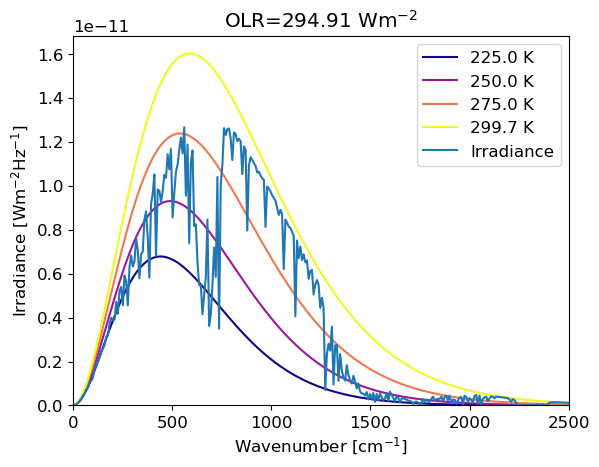

In [4]:
# Plotting.
import matplotlib
font = {'size'   : 12}
matplotlib.rc('font', **font)

wn = convert.freq2kaycm(f)

temps = [225, 250, 275, atmfield.get("T", keep_dims=False)[0]]
temp_colors = cmap2rgba("plasma", len(temps))

fig, ax = plt.subplots()
for t, color in sorted(zip(temps, temp_colors)):
    ax.plot(
        wn, np.pi * planck(f, t), label=f"{t:3.1f} K", color=color
    )
ax.plot(wn, olr, color="C0", label="Irradiance")
ax.legend()
ax.set_title(rf"OLR={np.trapezoid(olr, f):3.2f} $\sf Wm^{{-2}}$")
ax.set_xlim(wn.min(), wn.max())
ax.set_xlabel(r"Wavenumber [$\sf cm^{-1}$]")
ax.set_ylabel(r"Irradiance [$\sf Wm^{-2}Hz^{-1}$]")
ax.set_ylim(bottom=0)
fig.savefig("plots/tropicalolr.pdf")

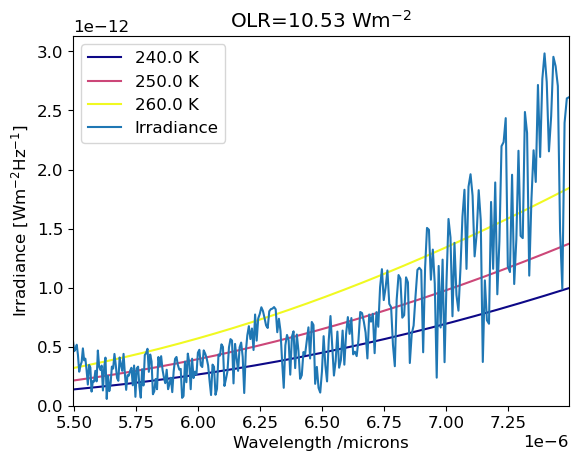

In [141]:
# Plotting for my frequency range: WV channels 
#f8, BT8_6_2, od = run_arts(species, zenith_angle, height, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6)
#f9, BT9_6_9, od = run_arts(species, zenith_angle, height, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.7e-6)
#f10,BT10_7_3,od = run_arts(species, zenith_angle, height, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.2e-6)

f, olr = calc_olr_from_atmfield(atmfield, verbosity=3, fmin=3e8/ 7.5e-6, fmax=3e8/ 5.5e-6) # 5-8 microns 

wn = convert.freq2kaycm(f)
wl = convert.freq2wavelen(f)

temps = [240, 250, 260] # surface T , atmfield.get("T", keep_dims=False)[0]]
temp_colors = cmap2rgba("plasma", len(temps))

fig, ax = plt.subplots()
for t, color in sorted(zip(temps, temp_colors)):
    ax.plot(
        wl, np.pi * planck(f, t), label=f"{t:3.1f} K", color=color
    )
ax.plot(wl, olr, color="C0", label="Irradiance")
ax.legend()
ax.set_title(rf"OLR={np.trapezoid(olr, f):3.2f} $\sf Wm^{{-2}}$")
ax.set_xlim(wl.min(), wl.max())
ax.set_xlabel(r"Wavelength /microns")
ax.set_ylabel(r"Irradiance [$\sf Wm^{-2}Hz^{-1}$]")
ax.set_ylim(bottom=0)
fig.savefig("plots/tropicalWVolr.pdf")

In [6]:
# Channel TB from OLR integral over that band 
def TB_from_olr(f,olr):
    temps = np.arange(200,320,1)  # a range of plausible temperatures (K) to interpolate linearly among
    FBs = []                      # Blackbody fluxes corresponding to above 
    for t in temps:
        FBs.append( np.trapezoid(np.pi * planck(f, t), f) )

    myF = np.trapezoid(olr, f)
    TB_interp = np.interp(myF, FBs, temps)
    
    return TB_interp

In [110]:
# Expressing WV channel fluxes as TB

#atmfield = xml.load("input/midlatitude-summer.xml")
atmfield = xml.load("input/tropical.xml")

f8, olr8 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
f9, olr9 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
f10,olr10= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 

# Interpolate to estimate TB 
T8 = TB_from_olr(f8, olr8)
T9 = TB_from_olr(f9, olr9)
T10= TB_from_olr(f10,olr10)

T8,T9,T10

# tropical result: (np.float64(239.2115082729545),np.float64(246.7849296175453),np.float64(257.61776619876883))

(np.float64(239.21150827295443),
 np.float64(246.78492961754526),
 np.float64(257.61776619876883))

-------------------
# Ready to perturb! 
from olr_module.py: 

    vmr = atmfield.get("abs_species-H2O")
    T = atmfield.get("T")
    p = atmfield.grids[1][:].reshape(T.shape)

That shape is (1, 46, 1, 1)

    # update atmosphere field
    atmfield.set("T", T + DeltaT)
    atmfield.set("abs_species-H2O", vmr)
    

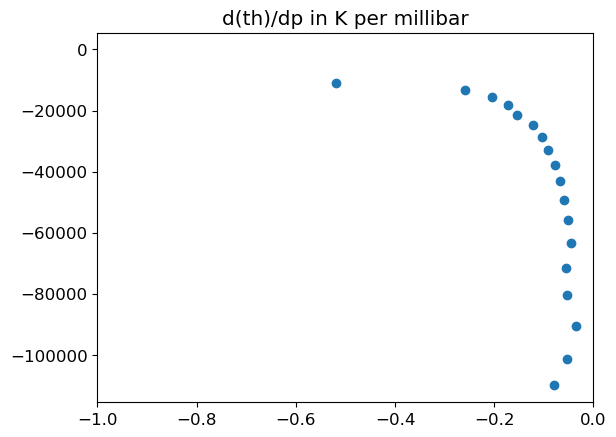

In [121]:
# Construct a potential temperature and its derivative: sensibility check passed
# d(th)/dp <0, yes checked

atmfield = xml.load("input/tropical.xml")
T = atmfield.get("T")
q = atmfield.get("abs_species-H2O")
p = atmfield.grids[1][:].reshape(T.shape)

th= T * ((100000./(p))**(287./1004))
dthdp = np.gradient(np.squeeze(th))/np.gradient(np.squeeze(p))
dqdp = np.gradient(np.squeeze(q))/np.gradient(np.squeeze(p))

# Quick plot vs. -p 
plt.scatter( dthdp*100, -np.squeeze(p) )
plt.xlim([-1,0])
plt.title('d(th)/dp in K per millibar');

In [120]:
# Quick look for dqdp: yes it makes sense in sign and size
#plt.scatter( dqdp*10000*1000, -np.squeeze(p) )
#plt.title('d(q)/dp in g/kg per 100 millibar');

# Kernel type approach: small 1mb upward motion of q, theta profiles at each level 
## (about 50mb spacing, but varies). 
## (should normalize by layer depth to make a true kernel, if linearity pans out)

In [ ]:
# TB change due to local level perturbations to q and/or T, each scaled to vertical displacements of 1mb

# Container for results 
DT8s_th = []
DT8s_q  = []
DT8s_bo = [] 
DT9s_th = []
DT9s_q  = []
DT9s_bo = [] 
DT10s_th = []
DT10s_q  = []
DT10s_bo = [] 


for ilev in np.arange(1,23): 
    print(ilev) 
    atmfield = xml.load("input/tropical.xml")  # RESET TO ORIGINAL PROFILE
    q = atmfield.get("abs_species-H2O")
    T = atmfield.get("T")
    p = atmfield.grids[1][:].reshape(T.shape)

    dq =  dqdp[ilev] * 100. # a 1mb vertical displacement locally in this layer 
    dth= dthdp[ilev] * 100.  
    dT = dth * T[0,ilev,0,0]/th[0,ilev,0,0]  # convert to T units 

# T pert alone first; can add to T since it will be overwritten next time thru loop 
    T[0,ilev,0,0] += dT

    atmfield.set("T", T)
    f8, olr8 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
    f9, olr9 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
    f10,olr10= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 
    
    T8p = TB_from_olr(f8, olr8)
    T9p = TB_from_olr(f9, olr9)
    T10p= TB_from_olr(f10,olr10)

    DT8s_th.append(T8p - T8)
    DT9s_th.append(T9p - T9)
    DT10s_th.append(T10p - T10)

# Next, Both T and q perts 
    q[0,ilev,0,0] += dq

    atmfield.set("abs_species-H2O", q+dq)
    f8, olr8 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
    f9, olr9 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
    f10,olr10= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 
    
    T8p = TB_from_olr(f8, olr8)
    T9p = TB_from_olr(f9, olr9)
    T10p= TB_from_olr(f10,olr10)

    DT8s_bo.append(T8p - T8)
    DT9s_bo.append(T9p - T9)
    DT10s_bo.append(T10p - T10)

# Finally, q pert alone, subtracting T pert which had been added above   
    T[0,ilev,0,0] -= dT
    atmfield.set("T", T)

    f8, olr8 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
    f9, olr9 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
    f10,olr10= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 
    
    T8p = TB_from_olr(f8, olr8)
    T9p = TB_from_olr(f9, olr9)
    T10p= TB_from_olr(f10,olr10)

    DT8s_q.append(T8p - T8)
    DT9s_q.append(T9p - T9)
    DT10s_q.append(T10p - T10)
    

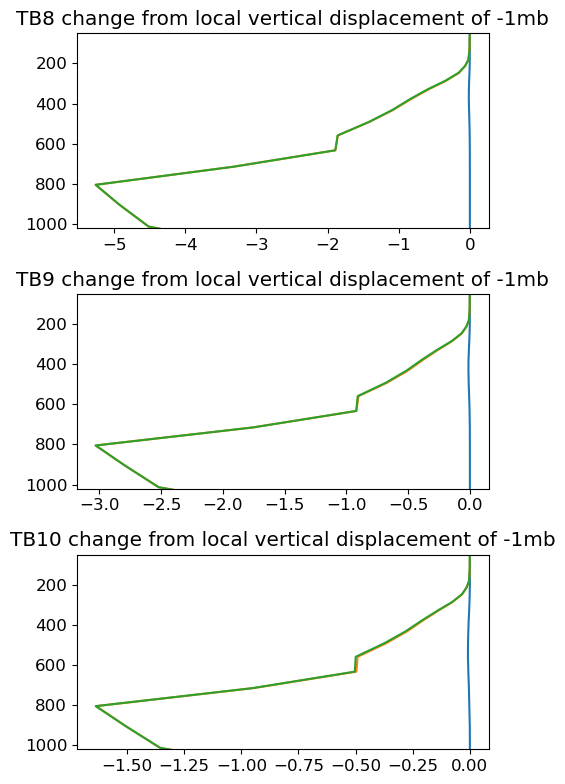

In [140]:
# Level by level sensitivity "kernel" d(Tb)/d(1mb displacement) for (q,theta,both): ABI WV channels 8,9,10
plt.figure(figsize=(5,8))

paxis = p[0,0:22,0,0]/100.

plt.subplot(311)
plt.plot(DT8s_th, paxis)
plt.plot(DT8s_q, paxis)
plt.plot(DT8s_bo, paxis)
plt.ylim([1020,50]);
plt.title('TB8 change from local vertical displacement of -1mb')

plt.subplot(312)
plt.plot(DT9s_th, paxis)
plt.plot(DT9s_q, paxis)
plt.plot(DT9s_bo, paxis)
plt.ylim([1020,50]);
plt.title('TB9 change from local vertical displacement of -1mb')

plt.subplot(313)
plt.plot(DT10s_th, paxis)
plt.plot(DT10s_q, paxis)
plt.plot(DT10s_bo, paxis)
plt.ylim([1020,50]);
plt.title('TB10 change from local vertical displacement of -1mb')

plt.tight_layout()

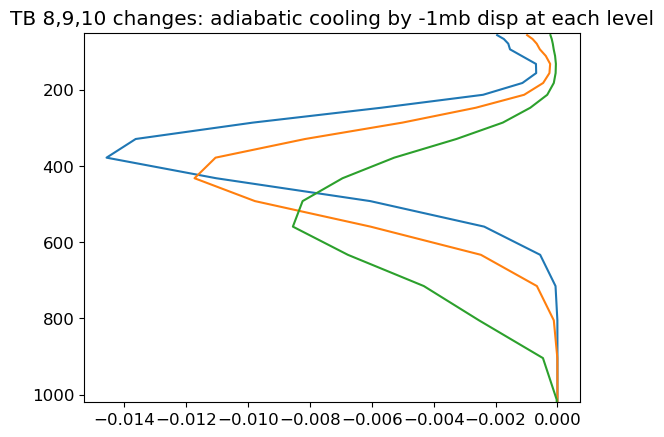

In [21]:
plt.plot(DT8s_th, paxis)
plt.plot(DT9s_th, paxis)
plt.plot(DT10s_th, paxis);
plt.ylim([1020,50]);
plt.title('TB 8,9,10 changes: adiabatic cooling by -1mb disp at each level');

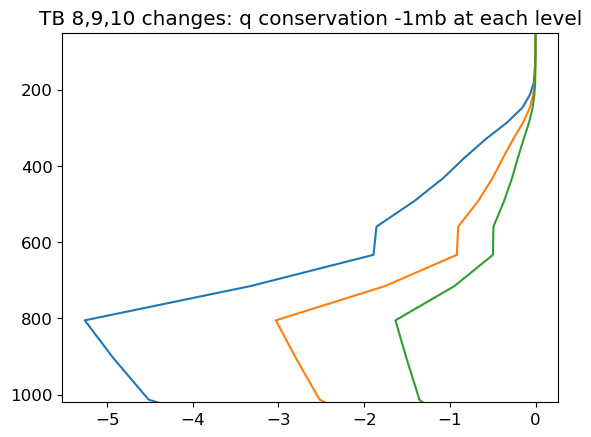

In [22]:
plt.figure()
plt.plot(DT8s_q, paxis)
plt.plot(DT9s_q, paxis)
plt.plot(DT10s_q, paxis);
plt.ylim([1020,50]);
plt.title('TB 8,9,10 changes: q conservation -1mb at each level');

# Use 10mb displacement instead of 1mb to test linearity 

In [23]:
# Do it for 10mb to see how linear it is 
# Consider TB change due to local perturbations to T and q, each scaled to vertical displacements of 1mb

# Container for results 
DT8s_th10 = []
DT8s_q10  = []
DT8s_bo10 = [] 
DT9s_th10 = []
DT9s_q10  = []
DT9s_bo10 = [] 
DT10s_th10 = []
DT10s_q10  = []
DT10s_bo10 = [] 


for ilev in np.arange(1,23): 
    # print(ilev) 
    atmfield = xml.load("input/tropical.xml")  # RESET TO ORIGINAL PROFILE
    q = atmfield.get("abs_species-H2O")
    T = atmfield.get("T")
    p = atmfield.grids[1][:].reshape(T.shape)

    dq =  dqdp[ilev] * 1000. # a 10mb vertial displacement locally in this layer 
    dth= dthdp[ilev] * 1000.  
    dT = dth * T[0,ilev,0,0]/th[0,ilev,0,0]  # convert to T units 

# T pert alone first; can add to T since it will be overwritten next time thru loop 
    T[0,ilev,0,0] += dT
    atmfield.set("T", T)
    
    f8, olr8 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
    f9, olr9 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
    f10,olr10= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 
    
    T8p = TB_from_olr(f8, olr8)
    T9p = TB_from_olr(f9, olr9)
    T10p= TB_from_olr(f10,olr10)

    DT8s_th10.append(T8p - T8)
    DT9s_th10.append(T9p - T9)
    DT10s_th10.append(T10p - T10)

# Next, Both T and q perts 
    q[0,ilev,0,0] += dq
    atmfield.set("abs_species-H2O", q)

    atmfield.set("abs_species-H2O", q+dq)
    f8, olr8 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
    f9, olr9 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
    f10,olr10= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 
    
    T8p = TB_from_olr(f8, olr8)
    T9p = TB_from_olr(f9, olr9)
    T10p= TB_from_olr(f10,olr10)

    DT8s_bo10.append(T8p - T8)
    DT9s_bo10.append(T9p - T9)
    DT10s_bo10.append(T10p - T10)

# Finally, q pert alone, subtracting T pert which had been added above   
    T[0,ilev,0,0] -= dT
    atmfield.set("T", T)

    f8, olr8 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
    f9, olr9 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
    f10,olr10= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 
    
    T8p = TB_from_olr(f8, olr8)
    T9p = TB_from_olr(f9, olr9)
    T10p= TB_from_olr(f10,olr10)

    DT8s_q10.append(T8p - T8)
    DT9s_q10.append(T9p - T9)
    DT10s_q10.append(T10p - T10)
    

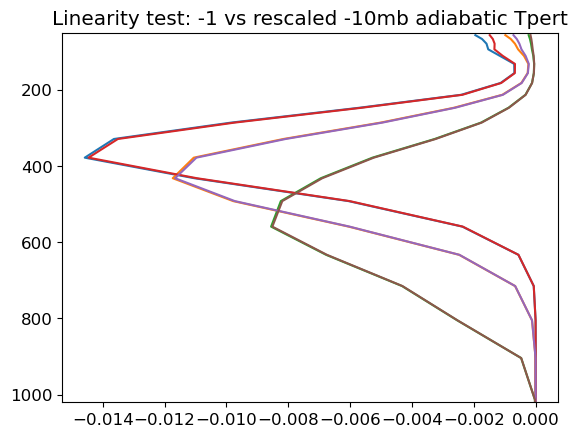

In [111]:
# How linear is T part alone? Very very very 
plt.plot(DT8s_th, paxis)
plt.plot(DT9s_th, paxis)
plt.plot(DT10s_th, paxis);
plt.plot(np.array(DT8s_th10)/10, paxis)
plt.plot(np.array(DT9s_th10)/10, paxis)
plt.plot(np.array(DT10s_th10)/10, paxis);

plt.ylim([1020,50]);
plt.title('Linearity test: -1 vs rescaled -10mb adiabatic Tpert');

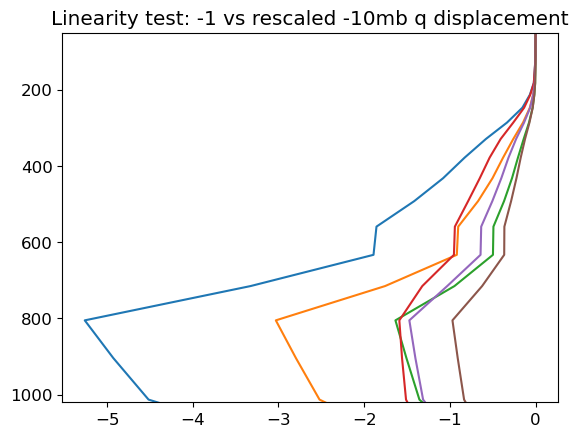

In [25]:
# How linea is the q effect? Not very!
plt.figure()
plt.plot(DT8s_q, paxis)
plt.plot(DT9s_q, paxis)
plt.plot(DT10s_q, paxis);
plt.plot(np.array(DT8s_q10)/10, paxis)
plt.plot(np.array(DT9s_q10)/10, paxis)
plt.plot(np.array(DT10s_q10)/10, paxis);

plt.ylim([1020,50]);
plt.title('Linearity test: -1 vs rescaled -10mb q displacement');  

# RESULT: very nonlinear! Or nonlocal, more to the point, since upper perturbations screen lower perturbations.  

### Nonlinear between dq due to 1mb and 10mb displacements: how so?

Can we interpret it? 

q perturbations at upper levels are changes to the emittance. That part is closer to linear, for instance the 10mb influence kernel or factor is closer to 10x (greater than 5x at least). The sensitivity to low level q is less than 5x bigger for a 10x vertical displacement, suggesting that the "micro windows" or "perforations" in the gray body are nearly saturated, so more and more perturbations to moisture q have a bounded or limited transmission to TOA where the sensor is. 

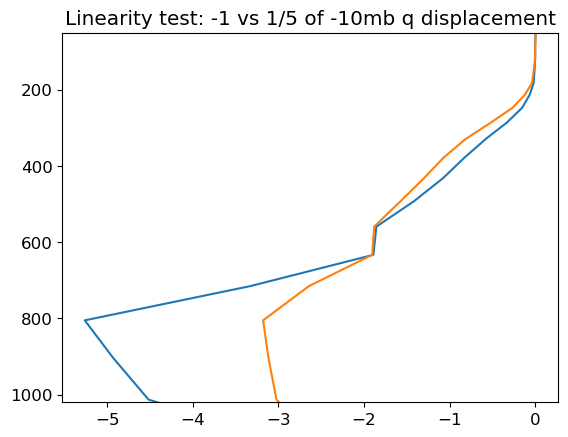

In [26]:
# Non linearity of q 1mb vs. 10mb, channel 8 
plt.figure()
plt.plot(DT8s_q, paxis)
#plt.plot(DT9s_q, paxis)
#plt.plot(DT10s_q, paxis);
plt.plot(np.array(DT8s_q10)/5, paxis)
#plt.plot(np.array(DT9s_q10)/10, paxis)
#plt.plot(np.array(DT10s_q10)/10, paxis);

plt.ylim([1020,50]);
plt.title('Linearity test: -1 vs 1/5 of -10mb q displacement');  


# Nonlinearity: WV channels are "perforated" not just gray 
Here is the result from BEMrtcalc from lecture-06 (radiance not irradiance) showing channel mean 8,9,10 Tb and the histogram of line by line Tb. 

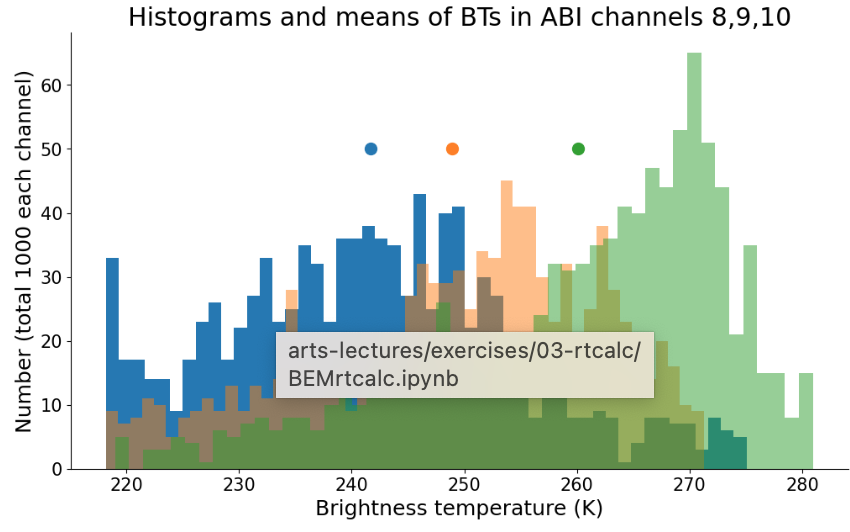


---------------------
---------------------
# Back to the measured thing: BT responses to GW-like time-integrated $\omega$ profiles 

Since the propagation speed of wavy features in d/dt(WV) channels is near c=13 m/s, and c is 1 wavelength per BV period (about 10 minutes), we can infer a **vertical wavelength near 13 * (10*60) = 7.8km**. 

So let's make a vertically bounded (tropospheric) $\omega$ sinusoid that is a solution to the GW equation with about 8km vertical wavelength, and plot its TB impact as a function of phase, spanning all vertical locations of node/antinodes relative to "the emission level" where T = Tb. 

# Fulton-Schubert 1985 modes of a tropical atmosphere 

Plot from my archives, could go off and compute with FORBET3.f modes codes (which Stefan Tulich translated into IDL). All codes are in **this [Box](https://miami.box.com/s/dglb5yf3cxxnjm70re0ls5dthajl2xeo) folder** if that were desired, here let's just fit the plot well enough.

Dotted line here is divergence for the 13 m/s mode of a COARE mean tropical N profile. That mode is essentially the prominent 3rd after subtracting convective and stratiform (Mapes & Houze 1996) 52,23 modes from the COARE IFA rawinsonde array wind divergence profile. See also Fig. 8 of Mapes 2000 QJ "Water's two height scales" paper.  

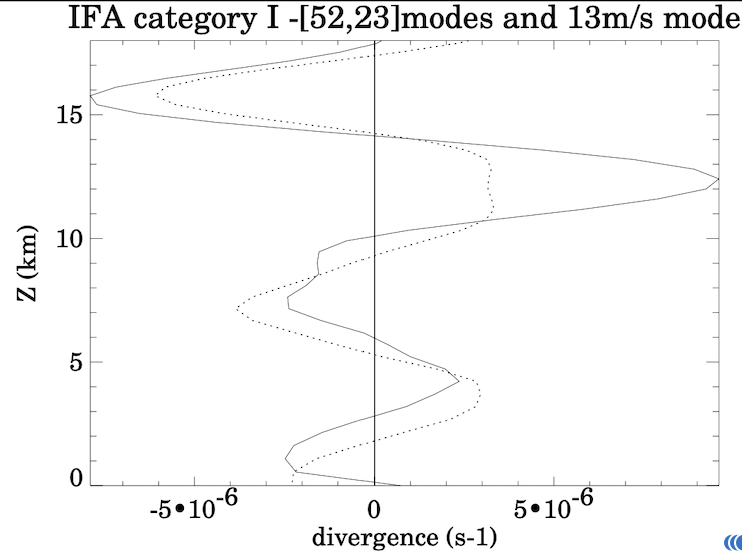

In [27]:
# Based on the above image, grab the nodes and antinodes 
div_Znodes       = np.array([1.9, 5.1, 9.0, 14.0, 17.2])*1000.   # m 
omega_Zantinodes = div_Znodes  
omega_Znodes     = np.array([0  , 3.5, 7.1, 12.1, 15.9])*1000.   # m 

In [117]:
# Get all the 4D squeezing done in prof arrays for profile clarity below 

Tprof = T[0,:,0,0]
pprof = p[0,:,0,0]
thprof=th[0,:,0,0]
qprof = q[0,:,0,0]
Zprof = -np.log(pprof/101300.) * 8000. # simple scale height approach 

In [29]:
# Nodes and antinodes in p 
omega_pantinodes = np.interp(omega_Zantinodes, Zprof, pprof)  #np.interp(x, xp, fp,
div_pnodes = omega_pantinodes
omega_pnodes = np.interp(omega_Znodes, Zprof, pprof)  #np.interp(x, xp, fp,

(101300.0, 10000.0)

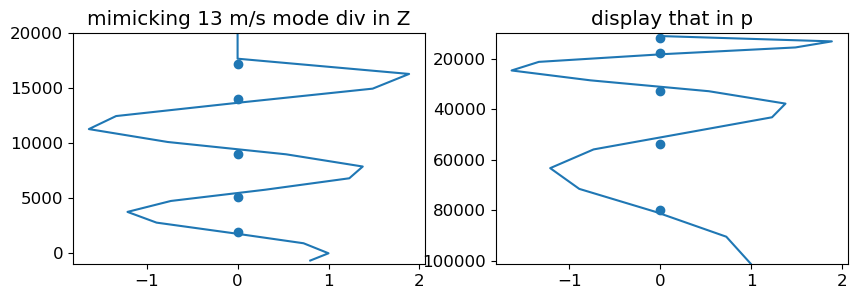

In [113]:
# Fit the dotted line: sinusoid with gently increasing with height wavelength 
# Weight it by a gently increasing with height factor

halfwavelength = 3500 + 300* abs((Zprof/10000))**1   # needs longer wavelengths in the upper trop
div = np.cos(Zprof/halfwavelength *np.pi) * (Zprof < 17000)  * (1 +Zprof/17000.) # amplitude increases w height

plt.figure(figsize=(10,3))
plt.subplot(121)
plt.plot(div, Zprof)
plt.scatter(div_Znodes*0, div_Znodes)
plt.ylim([-1000,20000])
plt.title('mimicking 13 m/s mode div in Z')

plt.subplot(122)
plt.plot(div, pprof)
plt.scatter(div_pnodes*0, div_pnodes)
plt.title('display that in p')
plt.ylim([101300,10000])

## For phase from -pi to pi, compute Tp and qp due to wave vertical motion 
### of 10 x the +/- 2mb range in hourly integrated omega from above

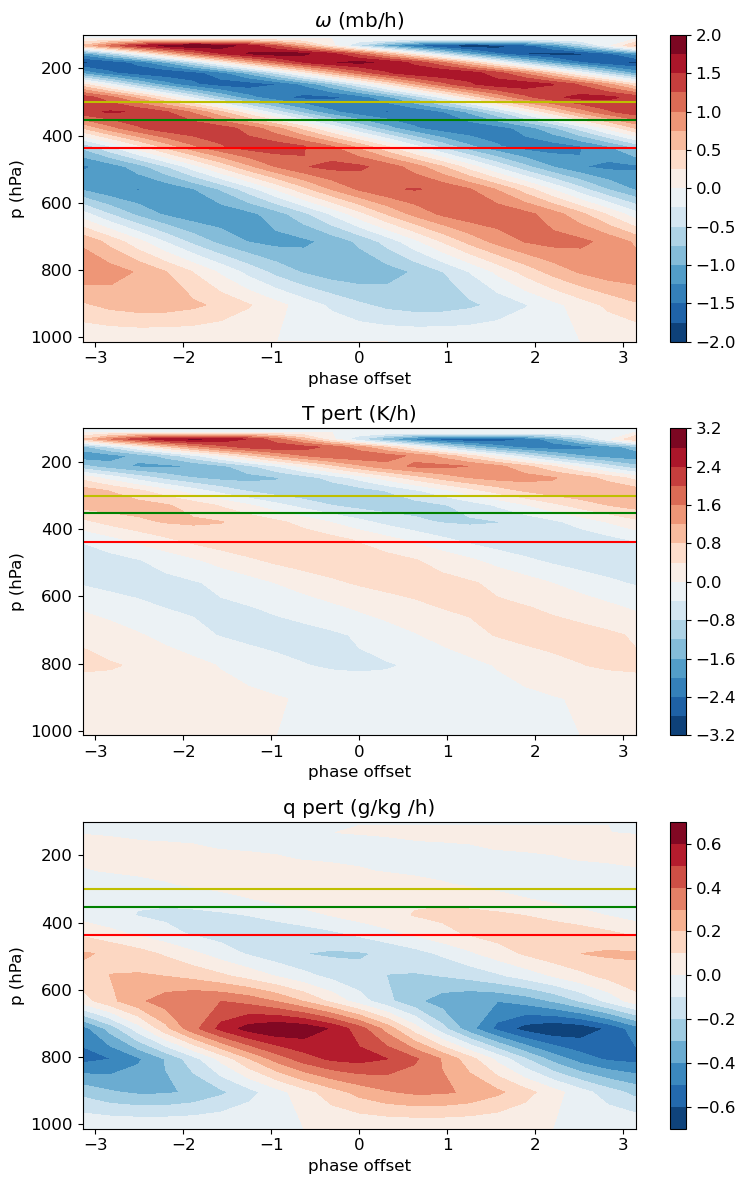

In [50]:
# For wavy omega profiles, replace cos with sin, and apply to get advective Tpert, qpert
# so that phase can be added to the argument to move wavy omega up or down in column
# Damp omega to zero at the surface as it must be, multiply by (1- exp(-zprof/2000) 

phase_offset = -np.pi + np.pi * np.arange(21)/10.  # 20 phases shoudl be enough resolution
Amplitude = 10.*100. # Pascals
om21 = np.zeros( (Zprof.size, phase_offset.size) ) 
Tp21 = np.zeros( (Zprof.size, phase_offset.size) ) 
qp21 = np.zeros( (Zprof.size, phase_offset.size) ) 

for i,ph in enumerate(phase_offset): 
    om21[:,i] = np.sin(Zprof/halfwavelength*np.pi + ph) * (Zprof < 17000)  * (1 +Zprof/17000) *(1- np.exp(- np.abs(Zprof)/1000.)) 
    qp21[:,i] = dqdp*Amplitude  * om21[:,i]
    Tp21[:,i] = dthdp*Amplitude * om21[:,i] / ((100000./(pprof))**(287./1004))

# Monotonic requirement on interp: use a negative sign
EL8 = np.interp(-T8,  -Tprof[1:15], pprof[1:15]) # must be in monotonic troposphere, 1:15
EL9 = np.interp(-T9,  -Tprof[1:15], pprof[1:15]) # must be in monotonic troposphere, 1:15
EL10= np.interp(-T10, -Tprof[1:15], pprof[1:15]) # must be in monotonic troposphere, 1:15


plt.figure( figsize=(8,12))

plt.subplot(311)
plt.contourf(phase_offset, pprof/100., -om21, 15, cmap='RdBu_r'); plt.colorbar()
plt.title('$\omega$ (mb/h)')
plt.ylim([1013,100]); plt.ylabel('p (hPa)')
plt.xlabel('phase offset')
plt.hlines(EL8/100, -np.pi, np.pi,'y'); plt.hlines(EL9/100, -np.pi, np.pi,'g'); plt.hlines(EL10/100,-np.pi, np.pi,'r');

plt.subplot(312)
plt.contourf(phase_offset, pprof/100., Tp21, 15, cmap='RdBu_r'); plt.colorbar()
plt.title('T pert (K/h)')
plt.ylim([1013,100]); plt.ylabel('p (hPa)')
plt.xlabel('phase offset')
plt.hlines(EL8/100, -np.pi, np.pi,'y'); plt.hlines(EL9/100, -np.pi, np.pi,'g'); plt.hlines(EL10/100,-np.pi, np.pi,'r');

plt.subplot(313)
plt.contourf(phase_offset, pprof/100., qp21*1000, 15, cmap='RdBu_r'); plt.colorbar()
plt.title('q pert (g/kg /h)')
plt.ylim([1013,100]); plt.ylabel('p (hPa)')
plt.xlabel('phase offset')
plt.hlines(EL8/100, -np.pi, np.pi,'y'); plt.hlines(EL9/100, -np.pi, np.pi,'g'); plt.hlines(EL10/100,-np.pi, np.pi,'r');
plt.tight_layout()

In [ ]:
# RT Results for 10x the (+/-2 hPa) amplitude from sin() formula 

# Container for results 
DT8s_phase = []
DT9s_phase = []
DT10s_phase = []

for i,ph in enumerate(phase_offset): 
    print(i, ph)
    om21[:,i] = np.sin(Zprof/halfwavelength*np.pi + ph) * (Zprof < 17000)  * (1 +Zprof/17000) *(1- np.exp(- np.abs(Zprof)/1000.))

    atmfield = xml.load("input/tropical.xml")  # RESET TO ORIGINAL PROFILE, then get , perturb, and set 
    q = atmfield.get("abs_species-H2O")
    T = atmfield.get("T")
    p = atmfield.grids[1][:].reshape(T.shape)

    q[0,:,0,0] += qp21[:,i] 
    q = np.abs(q)            # had to clean up an infinitestimal negative in the stratosphere
    T[0,:,0,0] += Tp21[:,i]

    atmfield.set("abs_species-H2O", q)     # Set it for RT calculation
    atmfield.set("T", T)

    f8, olr8 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
    f9, olr9 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
    f10,olr10= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 
    
    T8p = TB_from_olr(f8, olr8)
    T9p = TB_from_olr(f9, olr9)
    T10p= TB_from_olr(f10,olr10)

    DT8s_phase.append(T8p - T8)
    DT9s_phase.append(T9p - T9)
    DT10s_phase.append(T10p - T10)

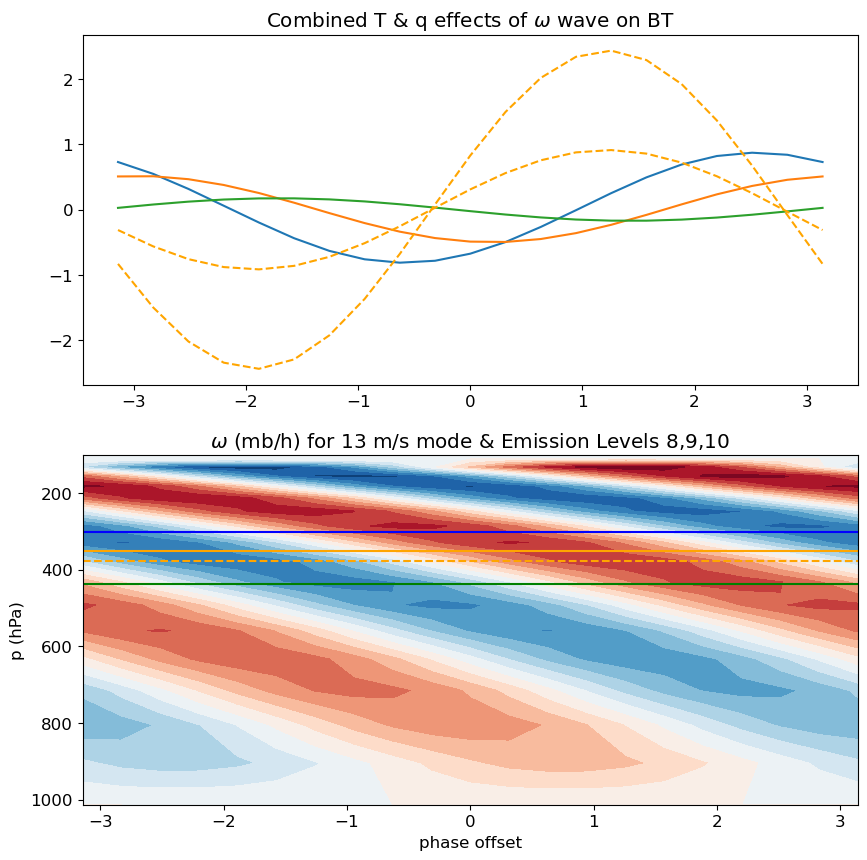

In [53]:
# Tropical Case Plot: TOA & omega for all phase offsets: dotted PB24 coefficient range @ 378mb "emission level"
plt.figure(figsize=(10,10) )

plt.subplot(211)           
plt.plot(phase_offset, DT8s_phase);
plt.plot(phase_offset, DT9s_phase);
plt.plot(phase_offset, DT10s_phase);
plt.title('Combined T & q effects of $\omega$ wave on BT')

# PB24 coefficient is "between 6 and 16 hPa per K" so overplot omega curve divided by this coefficient
# level 9 is 378 hPa 
plt.plot(phase_offset, Amplitude/100 *om21[9,:]/6., linestyle='--', color='orange') # convert omega at 378mb to BT using PB24 coefficient 
plt.plot(phase_offset, Amplitude/100 *om21[9,:]/16., linestyle='--', color='orange') # convert omega at 378mb to BT using PB24 coefficient 

plt.subplot(212)           
plt.contourf(phase_offset, pprof/100., om21, 15, cmap='RdBu_r')
plt.title('$\omega$ (mb/h) for 13 m/s mode & Emission Levels 8,9,10')
plt.ylim([1013,100]); plt.ylabel('p (hPa)')
plt.xlabel('phase offset')
plt.hlines(EL8/100, -np.pi, np.pi,'blue');
plt.hlines(EL9/100, -np.pi, np.pi,'orange');
plt.hlines(EL10/100,-np.pi, np.pi,'green');

plt.hlines(378,-np.pi, np.pi,'orange', linestyle='--'); #PB24 level

# Try it for a much drier column, halve the RH at upper levels 

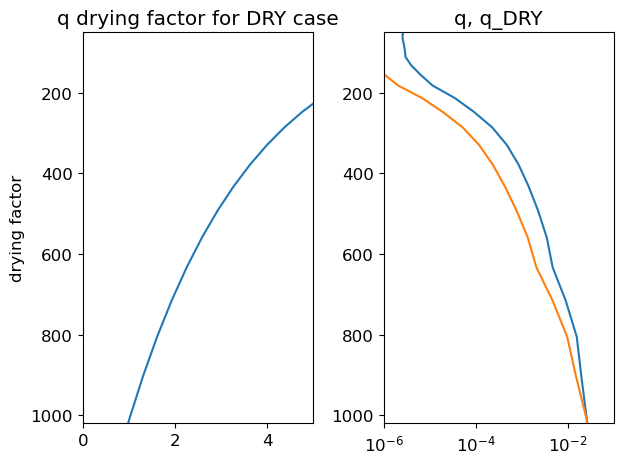

In [122]:
# RHfactor approach to drier atmosphere 
RHfactor = (1+ Zprof/3000)

plt.subplot(121)
plt.plot(RHfactor, pprof/100)
plt.ylim([1020, 50]); plt.ylabel('p /mb')
plt.xlim([0, 5]); plt.ylabel('drying factor')
plt.title('q drying factor for DRY case')

plt.subplot(122)
plt.semilogx(qprof, pprof/100)
plt.semilogx(qprof/RHfactor, pprof/100);
plt.ylim([1020, 50]);
plt.xlim([1e-6, 1e-1]);
plt.title('q, q_DRY')

plt.tight_layout()

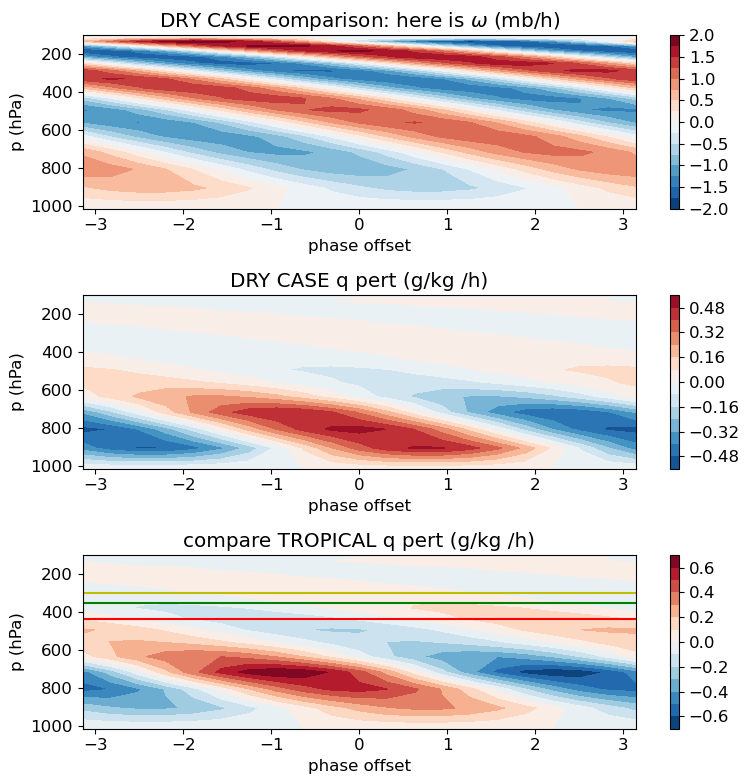

In [129]:
# Compare the q perturbation advecting the DRY CASE q profile (dqdp_dry)
Amplitude = 10.*100.  # 10 mb or hPa 

dqdp_dry = np.gradient(qprof/RHfactor)/np.gradient(pprof)
qp21_dry = np.zeros( (Zprof.size, phase_offset.size) ) 
for i,ph in enumerate(phase_offset): 
    om21[:,i] = np.sin(Zprof/halfwavelength*np.pi + ph) * (Zprof < 17000)  * (1 +Zprof/17000) *(1- np.exp(- np.abs(Zprof)/1000.)) 
    qp21_dry[:,i] = dqdp_dry*Amplitude  * om21[:,i]

plt.figure( figsize=(8,8))

plt.subplot(311)
plt.contourf(phase_offset, pprof/100., -om21, 15, cmap='RdBu_r'); plt.colorbar()
plt.title('DRY CASE comparison: here is $\omega$ (mb/h)')
plt.ylim([1013,100]); plt.ylabel('p (hPa)')
plt.xlabel('phase offset')
#plt.hlines(EL8dry/100, -np.pi, np.pi,'y'); plt.hlines(EL9dry/100, -np.pi, np.pi,'g'); plt.hlines(EL10dry/100,-np.pi, np.pi,'r');

plt.subplot(312)
plt.contourf(phase_offset, pprof/100., qp21_dry*1000, 15, cmap='RdBu_r'); plt.colorbar()
plt.title('DRY CASE q pert (g/kg /h)')
plt.ylim([1013,100]); plt.ylabel('p (hPa)')
plt.xlabel('phase offset')
plt.clim([-0.6,0.6])
#plt.hlines(EL8dry/100, -np.pi, np.pi,'y'); plt.hlines(EL9dry/100, -np.pi, np.pi,'g'); plt.hlines(EL10dry/100,-np.pi, np.pi,'r');

plt.subplot(313)
plt.contourf(phase_offset, pprof/100., qp21*1000, 15, cmap='RdBu_r'); plt.colorbar()
plt.title('compare TROPICAL q pert (g/kg /h)')
plt.ylim([1013,100]); plt.ylabel('p (hPa)')
plt.xlabel('phase offset')
plt.hlines(EL8/100, -np.pi, np.pi,'y'); plt.hlines(EL9/100, -np.pi, np.pi,'g'); plt.hlines(EL10/100,-np.pi, np.pi,'r');
plt.tight_layout()

plt.tight_layout()


In [93]:
# Do the BASELINE RT for DRY tropical baseline 

atmfield = xml.load("input/tropical.xml")
q = atmfield.get("abs_species-H2O")
q[0,:,0,0] /= RHfactor 

atmfield.set("abs_species-H2O", q)     # Set dried q for baseline RT calculation

# Baseline
f8, olr8dry = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
f9, olr9dry = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
f10,olr10dry= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 

# Interpolate to estimate TB 
T8dry = TB_from_olr(f8, olr8dry)
T9dry = TB_from_olr(f9, olr9dry)
T10dry= TB_from_olr(f10,olr10dry)

T8dry,T9dry,T10dry        # (np.float64(246.0582500798685),np.float64(253.26956119737852),np.float64(263.63396379474887))
#T8,T9,T10 tropical result: (np.float64(239.2115082729545),np.float64(246.7849296175453),np.float64(257.61776619876883))

(np.float64(248.38471084374945),
 np.float64(255.56110517199417),
 np.float64(265.73924881728647))

In [ ]:
# DRY CASE compute RT Results for 10x (+/-2 hPa) sin() amplitude

# Container for results 
DT8sdry_phase = []
DT9sdry_phase = []
DT10sdry_phase = []

for i,ph in enumerate(phase_offset): 
    print(i, ph)
    om21[:,i] = np.sin(Zprof/halfwavelength*np.pi + ph) * (Zprof < 17000)  * (1 +Zprof/17000) *(1- np.exp(- np.abs(Zprof)/1000.))

    atmfield = xml.load("input/tropical.xml")  # RESET TO ORIGINAL PROFILE, then get , perturb, and set 
    q = atmfield.get("abs_species-H2O")
    T = atmfield.get("T")
    p = atmfield.grids[1][:].reshape(T.shape)

    q[0,:,0,0] /= RHfactor  # DRY BASELINE
    q[0,:,0,0] += qp21_dry[:,i] 
    T[0,:,0,0] += Tp21[:,i]
    q = np.abs(q)            # had to clean up an infinitestimal negative in the stratosphere

    atmfield.set("abs_species-H2O", q)     # Set state for RT calculation
    atmfield.set("T", T)

    f8, olr8_dry = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
    f9, olr9_dry = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
    f10,olr10_dry= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 
    
    T8p_dry = TB_from_olr(f8, olr8_dry)
    T9p_dry = TB_from_olr(f9, olr9_dry)
    T10p_dry= TB_from_olr(f10,olr10_dry)

    DT8sdry_phase.append(T8p_dry   - T8dry)
    DT9sdry_phase.append(T9p_dry   - T9dry)
    DT10sdry_phase.append(T10p_dry - T10dry)

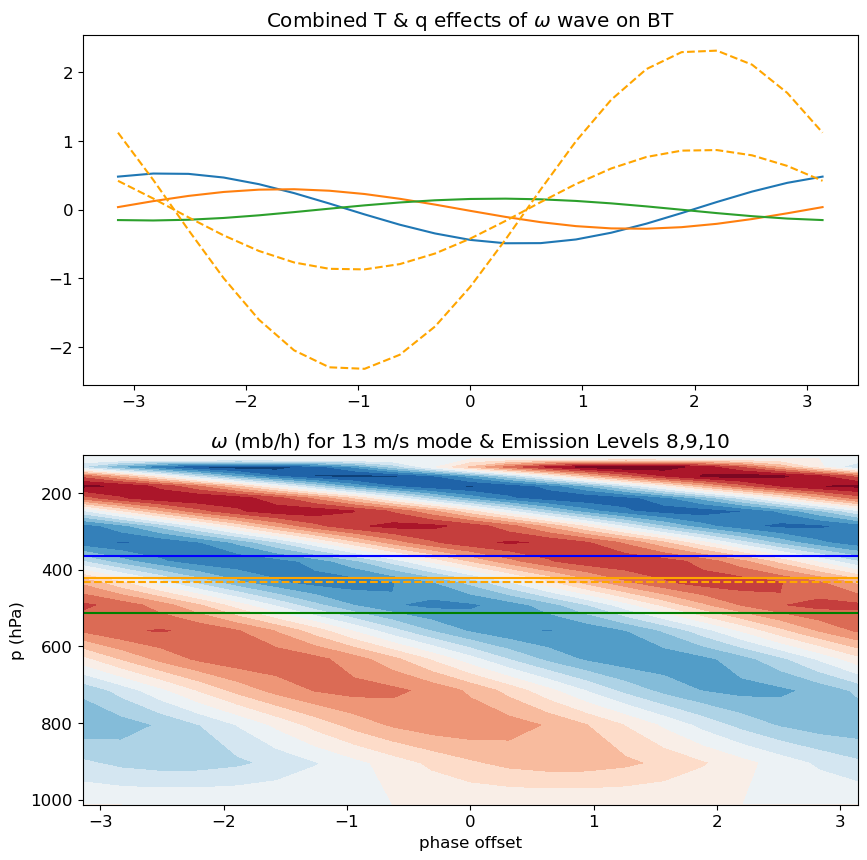

In [95]:
# Dry Tropical Case Plot, orange dash is PB24 coefficients times omega at "emission level" 432mb (pprof level 8)

# Dry case emission levels, Monotonic requirement on interp: use a negative sign
EL8dry = np.interp(-T8dry,  -Tprof[1:15], pprof[1:15]) # must be in monotonic troposphere= 1:15
EL9dry = np.interp(-T9dry,  -Tprof[1:15], pprof[1:15]) # must be in monotonic troposphere= 1:15
EL10dry= np.interp(-T10dry, -Tprof[1:15], pprof[1:15]) # must be in monotonic troposphere= 1:15


plt.figure(figsize=(10,10) )

plt.subplot(211)           
plt.plot(phase_offset, DT8sdry_phase);
plt.plot(phase_offset, DT9sdry_phase);
plt.plot(phase_offset, DT10sdry_phase);
plt.title('Combined T & q effects of $\omega$ wave on BT')

# PB24 coefficient is "between 6 and 16 hPa per K" so overplot omega curve divided by this coefficient
# Hardwire level 9 = 378 hPa NO DRY CASE 8=432mb
plt.plot(phase_offset, Amplitude/100 *om21[8,:]/6., linestyle='--', color='orange') # convert omega at 378mb to BT using PB24 coefficient 
plt.plot(phase_offset, Amplitude/100 *om21[8,:]/16., linestyle='--', color='orange') # convert omega at 378mb to BT using PB24 coefficient 

plt.subplot(212)           
plt.contourf(phase_offset, pprof/100., om21, 15, cmap='RdBu_r')
plt.title('$\omega$ (mb/h) for 13 m/s mode & Emission Levels 8,9,10')
plt.ylim([1013,100]); plt.ylabel('p (hPa)')
plt.xlabel('phase offset')
plt.hlines(EL8dry/100, -np.pi, np.pi,'blue');
plt.hlines(EL9dry/100, -np.pi, np.pi,'orange');
plt.hlines(EL10dry/100,-np.pi, np.pi,'green');

# Hardwire level 9 = 378 hPa NO DRY CASE 8=432mb
plt.hlines(432.,-np.pi, np.pi,'orange', linestyle='--'); #378mb level where PB24 coefficients are applied

# How about for the deep (50 m/s) internal GW mode? 
## whole-troposphere subsidence, or at least monopole in sign
### It's not the propagation speed we see in d/dt(WV) data, but seems to be in PB24's minds, and it does exist of course

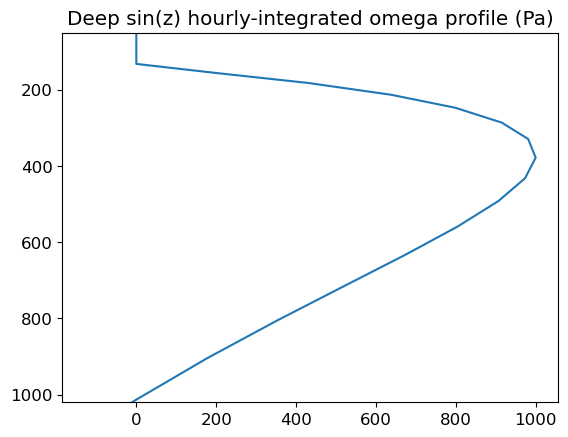

In [105]:
# Construct a deep tropospheric omega profile with 10mb amplitude

omdeep = 10*100 * np.sin(Zprof/16000*np.pi) * (Zprof < 16000) 
plt.plot(omdeep, pprof/100); plt.ylim([1020,50]); plt.title('Deep sin(z) hourly-integrated omega profile (Pa)');

In [134]:
# Tb change from Deep Omega 10mb amplitude in TROPICAL, compare PB24 "6 to 16 Pa/K for various soundings"

qpdeep = dqdp  * omdeep
thpdeep= dthdp * omdeep
Tpdeep = thpdeep / ((100000./(pprof))**(287./1004))

# Do the RT for Deep Omega perturbation

atmfield = xml.load("input/tropical.xml")
q = atmfield.get("abs_species-H2O")
T = atmfield.get("T")

q[0,:,0,0] += qpdeep 
T[0,:,0,0] += Tpdeep
atmfield.set("abs_species-H2O",np.abs(q))  # np.abs in case any stratospheric negatives or something    
atmfield.set("T", T)

# Baseline
f8, olr8deep = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
f9, olr9deep = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
f10,olr10deep= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 

# Interpolate to estimate TB 
T8deep = TB_from_olr(f8, olr8deep)
T9deep = TB_from_olr(f9, olr9deep)
T10deep= TB_from_olr(f10,olr10deep)

print( T8deep-T8,T9deep-T9,T10deep-T10, ' compare ', 10/16.,-10/6.)
#T8,T9,T10 tropical result: (np.float64(239.2115082729545),np.float64(246.7849296175453),np.float64(257.61776619876883))

-1.5564842014738076 -1.4181377004373985 -1.1662436770764657  compare  0.625 -1.6666666666666667


In [137]:
# DRY TROPICAL Tb change from Deep Omega 10mb, compare to PB24 "6 to 16 Pa/K for various soundings"

qpdeepd = dqdp_dry  * omdeep
thpdeepd= dthdp     * omdeep
Tpdeepd = thpdeep / ((100000./(pprof))**(287./1004))

# Do the RT for Deep Omega perturbation, Dry case

atmfield = xml.load("input/tropical.xml")
q = atmfield.get("abs_species-H2O")
T = atmfield.get("T")

q[0,:,0,0] /= RHfactor  # DRY CASE
q[0,:,0,0] += qpdeepd 
T[0,:,0,0] += Tpdeepd
atmfield.set("abs_species-H2O",np.abs(q))  # np.abs in case any stratospheric negatives or something    
atmfield.set("T", T)

# Baseline
f8, olr8deepd = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
f9, olr9deepd = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
f10,olr10deepd= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 

# Interpolate to estimate TB 
T8deepd = TB_from_olr(f8, olr8deepd)
T9deepd = TB_from_olr(f9, olr9deepd)
T10deepd= TB_from_olr(f10,olr10deepd)

print( T8deepd-T8dry,T9deepd-T9dry,T10deepd-T10dry, ' compare ', 10/16.,-10/6.)
#T8,T9,T10 tropical result: (np.float64(239.2115082729545),np.float64(246.7849296175453),np.float64(257.61776619876883))

-1.608164081190921 -1.377788411246911 -1.0559099702758203  compare  0.625 -1.6666666666666667


# For that deep mode, the PB24 coefficient is about right, although 6Pa/K is closer than 16 Pa/K

# Sidebar: 13 m/s wave result if T only (not q) was adiabatically warmed/cooled

In [ ]:
# Wave Results for advection of theta only (in phase with omega at ELs, but small) 

# Container for results 
DT8s_phaseT = []
DT9s_phaseT = []
DT10s_phaseT= []

for i,ph in enumerate(phase_offset): 
    print(i, ph)
    om21[:,i] = np.sin(Zprof/halfwavelength*np.pi + ph) * (Zprof < 17000)  * (1 +Zprof/17000) *(1- np.exp(- np.abs(Zprof)/1000.))

    atmfield = xml.load("input/tropical.xml")  # RESET TO ORIGINAL PROFILE, then get , perturb, and set 
    q = atmfield.get("abs_species-H2O")
    T = atmfield.get("T")
    p = atmfield.grids[1][:].reshape(T.shape)

    q[0,:,0,0] += qp21[:,i] 
    q = np.abs(q)            # had to clean up an infinitestimal negative in the stratosphere
    T[0,:,0,0] += Tp21[:,i]

#    atmfield.set("abs_species-H2O", q)     # DO NOT Set it for RT calculation
    atmfield.set("T", T)

    f8, olr8 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
    f9, olr9 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
    f10,olr10= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 
    
    T8p = TB_from_olr(f8, olr8)
    T9p = TB_from_olr(f9, olr9)
    T10p= TB_from_olr(f10,olr10)

    DT8s_phaseT.append(T8p - T8)
    DT9s_phaseT.append(T9p - T9)
    DT10s_phaseT.append(T10p - T10)

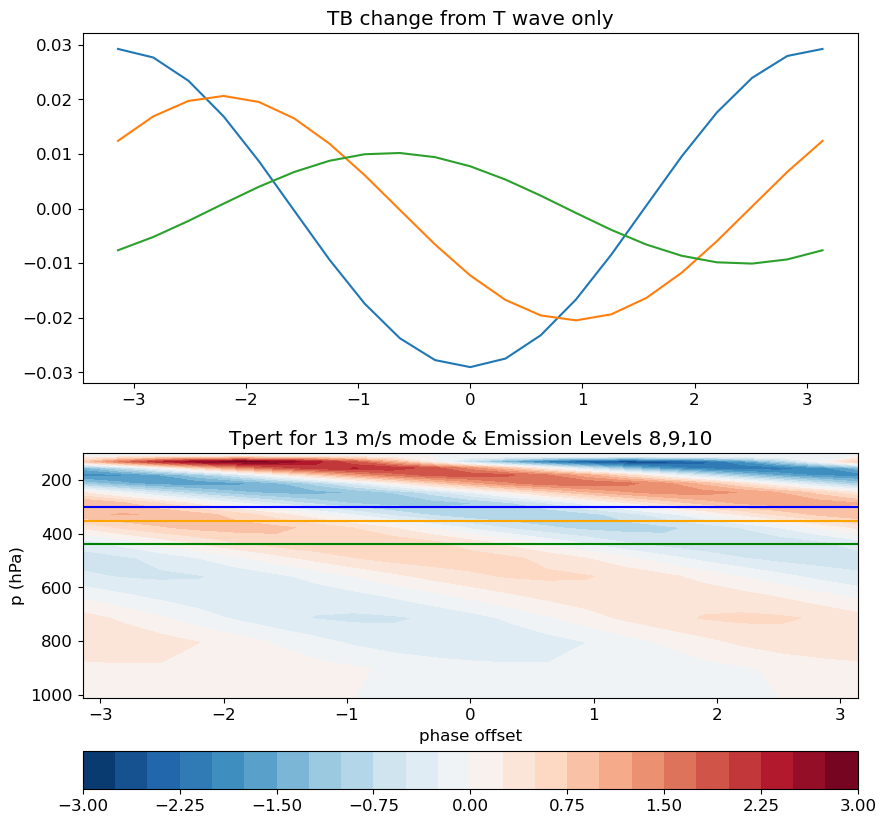

In [139]:
# Plot of TB change from adiabatic T only 
plt.figure(figsize=(10,10) )

plt.subplot(211)           
plt.plot(phase_offset, DT8s_phaseT);
plt.plot(phase_offset, DT9s_phaseT);
plt.plot(phase_offset, DT10s_phaseT);
plt.title('TB change from T wave only')

plt.subplot(212)           
plt.contourf(phase_offset, pprof/100., Tp21, 25, cmap='RdBu_r')
plt.title('Tpert for 13 m/s mode & Emission Levels 8,9,10')
plt.ylim([1013,100]); plt.ylabel('p (hPa)')
plt.xlabel('phase offset')
plt.hlines(EL8/100, -np.pi, np.pi,'blue');
plt.hlines(EL9/100, -np.pi, np.pi,'orange');
plt.hlines(EL10/100,-np.pi, np.pi,'green');

plt.colorbar(location='bottom')